<a href="https://colab.research.google.com/github/snig-17/QM-GRUNGE/blob/main/year_season.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Convert Year/Season → numeric year

Use logistic regression to test whether success probability changes over time

(Optional) Report a point-biserial correlation as a descriptive check

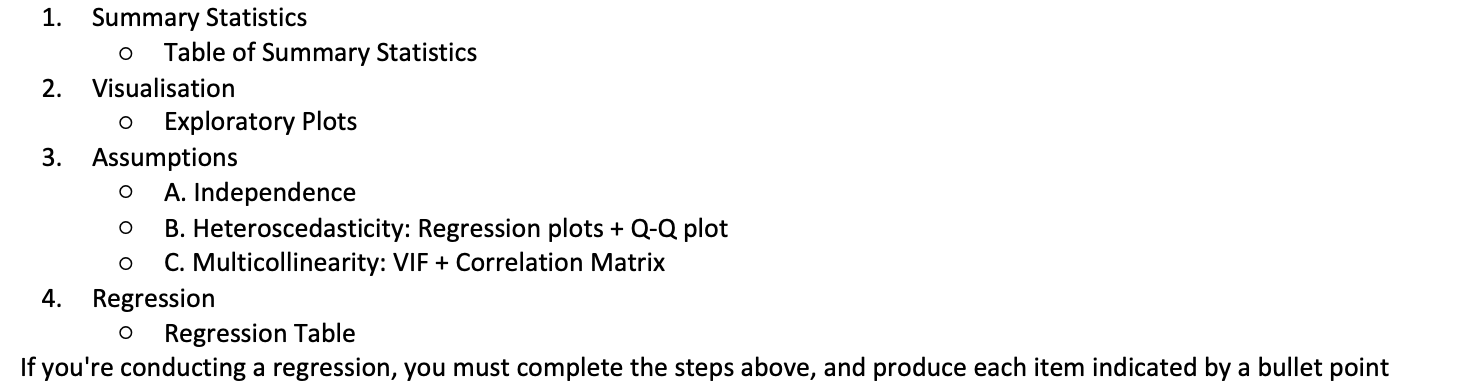

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
#same imports as the Week 8 DiD workshop
%matplotlib inline

import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
import pylab
import pandas as pd
import numpy as np

from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.iolib.summary2 import summary_col
import statsmodels.formula.api as smf

pylab.rcParams['figure.figsize'] = (10., 8.)
sns.set(font_scale=1.2)
sns.set_style("white")


In [ ]:
df = pd.read_csv( "/content/drive/MyDrive/QM_Grunge_Data/expeditions4.csv")

df.head()



,Yr/Seas,Host,Nationalities,Leader(s),Route(s),Result,Smtrs,Dead,ExpedID,Year,...,hired_count,hired_DR,mbr_DR,mbr_hired_ratio,total_DR,clean_routes,route_codes,result_clean,result_code,success_rate
0,1990 Spr,China,W Germany/Iran,Mischa Saleki,W Ridge from N,Route Difficulty,NaN,NaN,EVER-901-01,1990,...,0,0.0,0.0,0.00,0.0,w ridge from n,6,route difficulty,3,0
1,1990 Spr,China,"USA, Austria, Canada, Spain",Todd Burleson,W Ridge from N,"Illness, AMS",NaN,NaN,EVER-901-02,1990,...,4,0.0,0.0,0.31,0.0,w ridge from n,6,"illness, ams",4,0
2,1990 Spr,China,"USA, China, USSR","Jim Whittaker, Vladimir Shataev, Lobsang Dawa",N Col-NE Ridge,Success,20.0,NaN,EVER-901-03,1990,...,0,0.0,0.0,0.00,0.0,n col-ne ridge,2,success,1,1
3,1990 Spr,Nepal,Nepal,Chetra Bahadur Gurung,S Col-SE Ridge,Success,4.0,NaN,EVER-901-04,1990,...,2,0.0,0.0,0.08,0.0,s col-se ridge,1,success,1,1
4,1990 Spr,Nepal,Switzerland,Beda Fuster,Lho La-W Ridge (to 7450m) / S Col-SE Ridge (to...,"Illness, AMS",NaN,NaN,EVER-901-05,1990,...,0,0.0,0.0,0.00,0.0,lho la-w ridge,6,"illness, ams",4,0


In [ ]:
print(df.columns)
print(df.shape)


Index(['Yr/Seas', 'Host', 'Nationalities', 'Leader(s)', 'Route(s)', 'Result',
       'Smtrs', 'Dead', 'ExpedID', 'Year', 'expedition_code', 'group_size',
       'total_members', 'death_mbrs', 'hired_deaths', 'hired_count',
       'hired_DR', 'mbr_DR', 'mbr_hired_ratio', 'total_DR', 'clean_routes',
       'route_codes', 'result_clean', 'result_code', 'success_rate'],
      dtype='object')
(2192, 25)


In [ ]:
# keep only the columns we need and drop missing values
df = df[["Yr/Seas", "success_rate"]].dropna().copy()

# extract the numeric year from "Yr/Seas" (e.g. "2019 Spring" → 2019)
df["Year"] = (
    df["Yr/Seas"]
    .str.extract(r"(\d{4})")
    .astype(int)
)

# ensure success_rate is numeric and binary (0 or 1 only)
df["success_rate"] = pd.to_numeric(df["success_rate"], errors="coerce")
df = df[df["success_rate"].isin([0, 1])]

In [ ]:
#Step 1: Summary statistics
summary = df[["success_rate", "Year"]].describe().round(3).T
summary[["count", "mean", "std", "min", "max"]]

,count,mean,std,min,max
success_rate,2192.0,0.673,0.469,0.0,1.0
Year,2192.0,2009.206,8.735,1990.0,2025.0


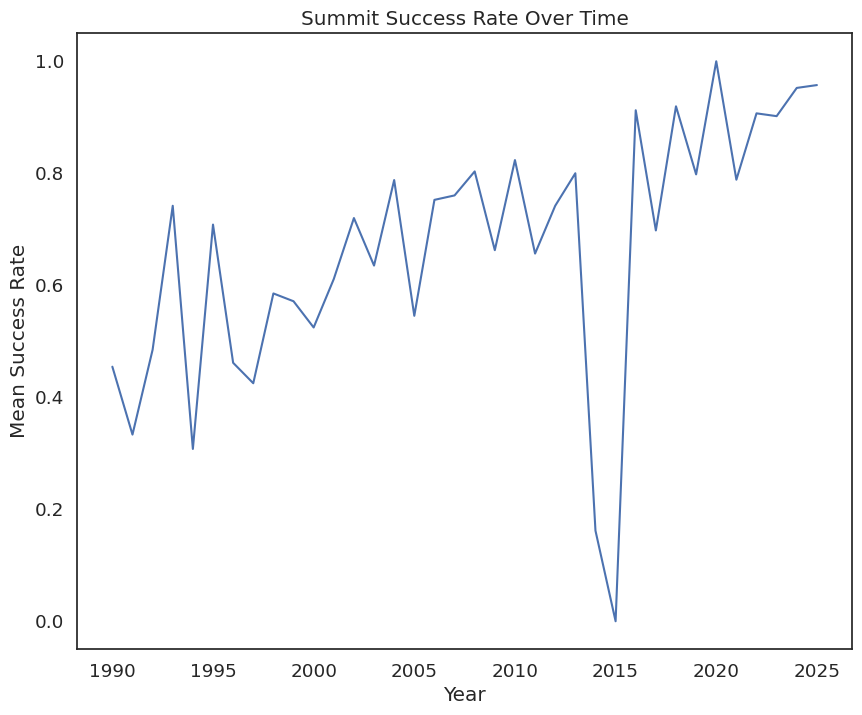

In [ ]:
#Step 2: Visualisation

#(A)Success Rate Over Time
yearly_success = df.groupby("Year")["success_rate"].mean().reset_index()

plt.figure()
plt.plot(yearly_success["Year"], yearly_success["success_rate"])
plt.xlabel("Year")
plt.ylabel("Mean Success Rate")
plt.title("Summit Success Rate Over Time")
plt.show()


Text(51.875, 0.5, 'Success Rate')

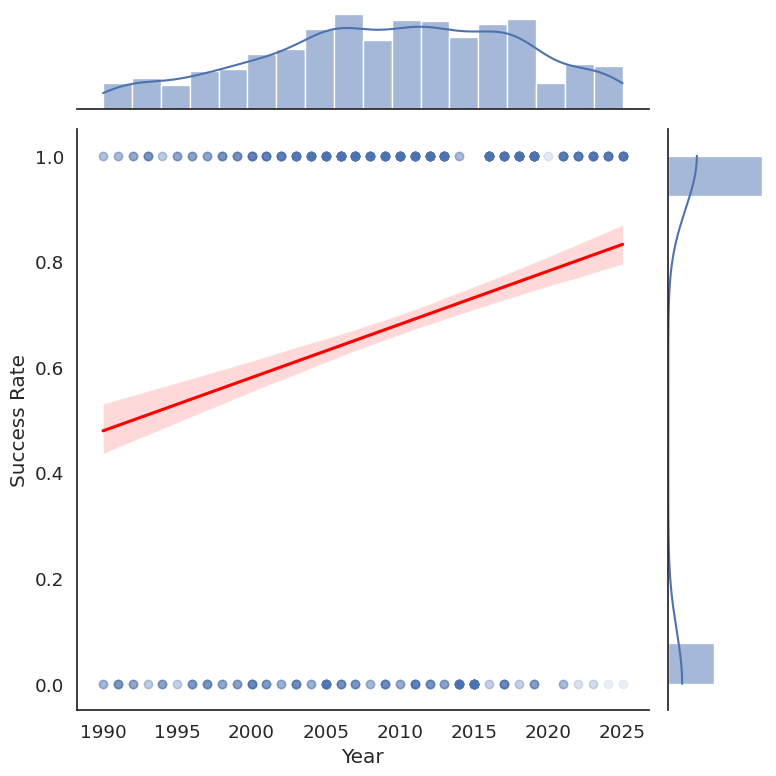

In [ ]:
#(B)Jointplot
sns.jointplot(
    data=df,#plot a scatterplot with a regression line and two histograms
    x="Year",
    y="success_rate",
    kind="reg",
    scatter_kws=dict(alpha=0.05),
    line_kws=dict(color="red"),
    height=8
)

plt.xlabel('Year') # add a label to the x axis
plt.ylabel('Success Rate') # add a label to the y axis

In [ ]:
#Step 3: Assumptions
#(A)Independence
print("Independence assumption: discuss whether observations are independent (e.g., climbers within same expedition may be correlated).")

#(B)Heteroscedasticity + Q-Q Plot
#Logistic regression does not assume homoscedastic errors. The variance of the dependent variable depends on the predicted probability and therefore varies across observations by design.
#Maybe need a better academic justification for this


Independence assumption: discuss whether observations are independent (e.g., climbers within same expedition may be correlated).


In [ ]:
#(C)Multicollinearity

#Will convert Seasons into dummy variables and do multicollinearity and VIF for both Year and Season

# Extract season from 'Yr/Seas' column
season_dummies = pd.get_dummies(
    df["season"],
    prefix="season",
    drop_first=True,
).astype(int)



# create dummy variables for season and convert them to integers
season_dummies = pd.get_dummies(df["season"], prefix="season").astype(int)

# combine with year
X_mc = pd.concat(
    [df[["Year"]], season_dummies],
    axis=1
)

X_mc.head()

,Year,season_Aut,season_Spr,season_Win
0,1990,0,1,0
1,1990,0,1,0
2,1990,0,1,0
3,1990,0,1,0
4,1990,0,1,0


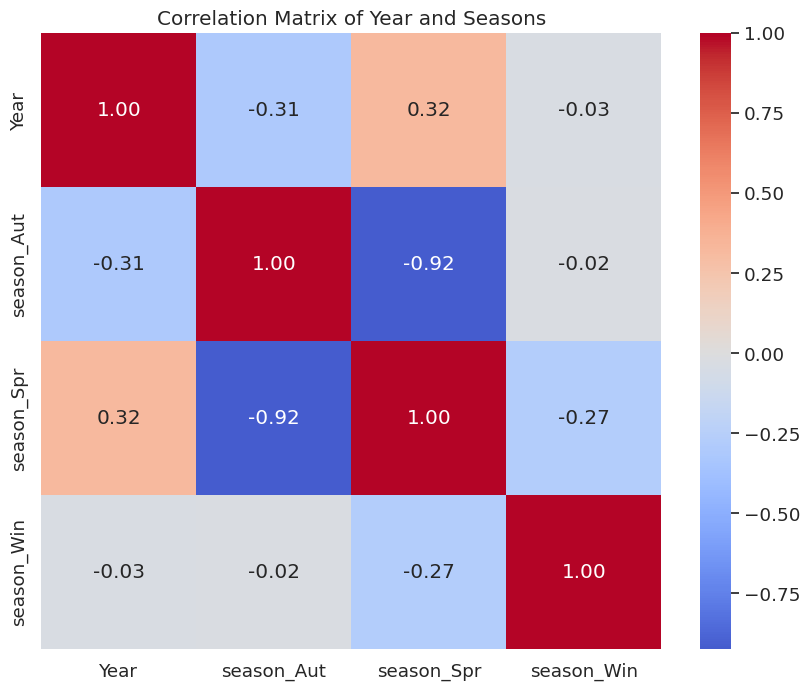

In [ ]:
#Correlation Matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.heatmap(
    X_mc.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix of Year and Seasons")
plt.show()

In [ ]:
#VIF (Variance Inflation Factor)

#VIF tells you how much a predictor’s variance is inflated because it is correlated with other predictors.

#If VIF = 1 → no correlation with other predictors → no inflation.
#If VIF = 5 → the variance of this coefficient is 5× bigger than it would be if this predictor were alone.
#If VIF = 10 → serious multicollinearity.

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import pandas as pd

def drop_column_using_vif_(df, list_var_not_to_remove=None, thresh=5):
    while True:
        df_with_const = add_constant(df)

        vif_df = pd.Series(
            [variance_inflation_factor(df_with_const.values, i)
             for i in range(df_with_const.shape[1])],
            name="VIF",
            index=df_with_const.columns
        ).to_frame()

        vif_df = vif_df.drop("const")

        if list_var_not_to_remove is not None:
            vif_df = vif_df.drop(list_var_not_to_remove, errors="ignore")

        print("Max VIF:", vif_df.VIF.max())

        if vif_df.VIF.max() > thresh:
            index_to_drop = vif_df.index[vif_df.VIF == vif_df.VIF.max()].tolist()[0]
            print("Dropping:", index_to_drop)
            df = df.drop(columns=index_to_drop)
        else:
            break

    return df


In [ ]:
season_cols = season_dummies.columns.tolist()

vif_selected = drop_column_using_vif_(
    X,
    list_var_not_to_remove=season_cols,  # protect the whole season dummy set
    thresh=5
)

print("Columns remaining after VIF selection:")
print(vif_selected.columns)


Max VIF: 0.999999999999998
Columns remaining after VIF selection:
Index(['const', 'Year'], dtype='object')


In [ ]:
#VIF (Variance Inflation Factor)

#VIF tells you how much a predictor’s variance is inflated because it is correlated with other predictors.

#If VIF = 1 → no correlation with other predictors → no inflation.
#If VIF = 5 → the variance of this coefficient is 5× bigger than it would be if this predictor were alone.
#If VIF = 10 → serious multicollinearity.

from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

# add constant
X_vif = add_constant(X_mc)

vif_df = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i)
            for i in range(X_vif.shape[1])]
})

vif_df

,Variable,VIF
0,const,58793.278910
1,Year,1.121408
2,season_Aut,14.916462
3,season_Spr,16.315849
4,season_Win,2.394381


In [ ]:
#Logistic regression
import statsmodels.api as sm

X = sm.add_constant(df["Year"])
y = df["success_rate"]

model = sm.Logit(y, X)
result = model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.614391
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:           success_rate   No. Observations:                 2192
Model:                          Logit   Df Residuals:                     2190
Method:                           MLE   Df Model:                            1
Date:                Wed, 07 Jan 2026   Pseudo R-squ.:                 0.02802
Time:                        11:49:28   Log-Likelihood:                -1346.7
converged:                       True   LL-Null:                       -1385.6
Covariance Type:            nonrobust   LLR p-value:                 1.225e-18
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -92.6839     10.781     -8.597      0.000    -113.815     -71.553
Year           0.0465      0.